
Dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  

Training data: 120
Testing data: 30

Model trained successfully!

MODEL PERFORMANCE
Accuracy: 90.0 %

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90  

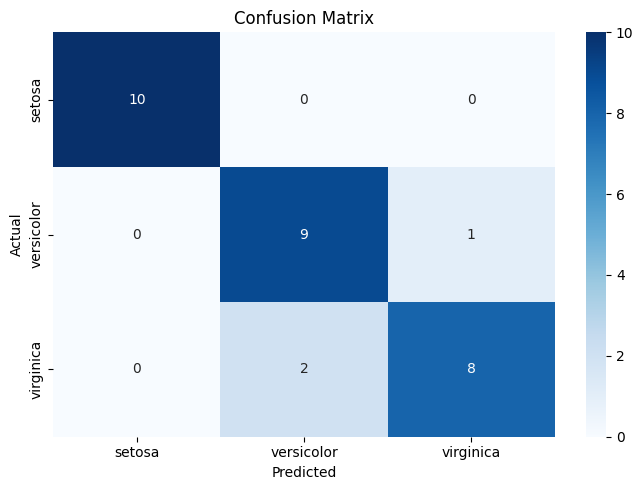

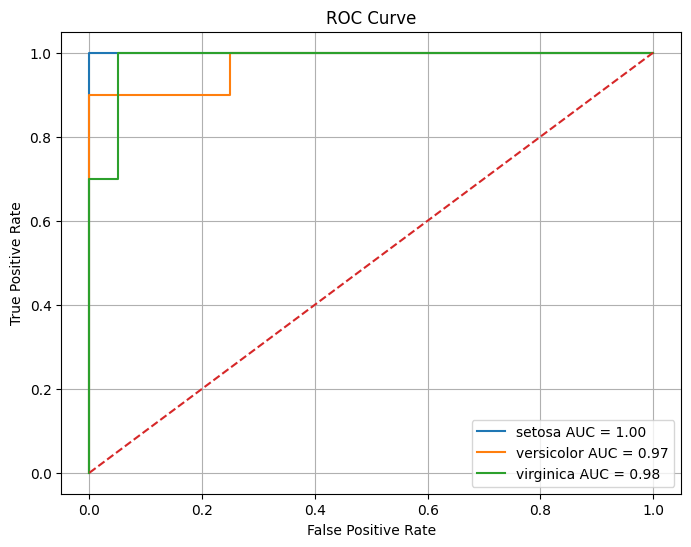


Feature Importance:
sepal length (cm) : 0.116
sepal width (cm) : 0.015
petal length (cm) : 0.431
petal width (cm) : 0.437

ENTER FLOWER MEASUREMENTS

Enter values in centimeters.


In [ ]:
# ============================================================
# PREDICTIVE MODELING USING MACHINE LEARNING
# Random Forest + User Input
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

from sklearn.preprocessing import label_binarize


# ============================================================
# 1. LOAD DATASET
# ============================================================

iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names
target_names = iris.target_names


# ============================================================
# 2. CREATE DATAFRAME
# ============================================================

df = pd.DataFrame(X, columns=feature_names)

df["target"] = y

print("\nDataset:")
print(df.head())


# ============================================================
# 3. SPLIT DATASET
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining data:", len(X_train))
print("Testing data:", len(X_test))


# ============================================================
# 4. CREATE MODEL
# ============================================================

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)


# ============================================================
# 5. TRAIN MODEL
# ============================================================

model.fit(X_train, y_train)

print("\nModel trained successfully!")


# ============================================================
# 6. TEST MODEL
# ============================================================

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\n==============================")
print("MODEL PERFORMANCE")
print("==============================")

print("Accuracy:", round(accuracy * 100, 2), "%")


# ============================================================
# 7. CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=target_names
    )
)


# ============================================================
# 8. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()

plt.show()


# ============================================================
# 9. ROC CURVE
# ============================================================

y_test_binary = label_binarize(
    y_test,
    classes=[0, 1, 2]
)

y_probability = model.predict_proba(X_test)

plt.figure(figsize=(8, 6))

for i in range(3):

    fpr, tpr, _ = roc_curve(
        y_test_binary[:, i],
        y_probability[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{target_names[i]} AUC = {roc_auc:.2f}"
    )


plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid()

plt.show()


# ============================================================
# 10. FEATURE IMPORTANCE
# ============================================================

importance = model.feature_importances_

print("\nFeature Importance:")

for feature, value in zip(feature_names, importance):

    print(
        feature,
        ":",
        round(value, 3)
    )


# ============================================================
# 11. USER INPUT
# ============================================================

print("\n========================================")
print("ENTER FLOWER MEASUREMENTS")
print("========================================")

print("\nEnter values in centimeters.")

sepal_length = float(
    input("Enter Sepal Length: ")
)

sepal_width = float(
    input("Enter Sepal Width: ")
)

petal_length = float(
    input("Enter Petal Length: ")
)

petal_width = float(
    input("Enter Petal Width: ")
)


# ============================================================
# 12. CREATE USER INPUT ARRAY
# ============================================================

user_data = np.array([
    [
        sepal_length,
        sepal_width,
        petal_length,
        petal_width
    ]
])


# ============================================================
# 13. PREDICT
# ============================================================

prediction = model.predict(user_data)

probability = model.predict_proba(user_data)


# ============================================================
# 14. DISPLAY RESULT
# ============================================================

predicted_flower = target_names[prediction[0]]

print("\n========================================")
print("PREDICTION RESULT")
print("========================================")

print(
    "Predicted Flower:",
    predicted_flower
)


# ============================================================
# 15. DISPLAY PROBABILITY
# ============================================================

print("\nPrediction Probability:")

for i in range(len(target_names)):

    print(
        target_names[i],
        ":",
        round(probability[0][i] * 100, 2),
        "%"
    )


print("\n========================================")
print("PROGRAM COMPLETED")
print("========================================")